In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Weather_Data.csv')
df.head()

,Date,City,Temperature (°C),Humidity (%),Wind Speed (km/h),Weather Condition
0,2021-12-07,West Rachel,38.9,75,29.0,Rainy
1,2020-08-30,Port Jill,37.7,67,2.7,Rainy
2,2025-04-19,Priscillafurt,6.8,86,8.6,Cloudy
3,2021-05-01,Jacobmouth,22.1,63,12.2,Sunny
4,2020-05-07,Moranhaven,30.2,39,0.6,Cloudy


In [ ]:
#converting weather conditions into binary
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Weather Condition']=le.fit_transform(df['Weather Condition'])
df.head()

,Date,City,Temperature (°C),Humidity (%),Wind Speed (km/h),Weather Condition
0,2021-12-07,West Rachel,38.9,75,29.0,1
1,2020-08-30,Port Jill,37.7,67,2.7,1
2,2025-04-19,Priscillafurt,6.8,86,8.6,0
3,2021-05-01,Jacobmouth,22.1,63,12.2,3
4,2020-05-07,Moranhaven,30.2,39,0.6,0


In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop(['Weather Condition', 'Date', 'City'],axis=1)
y=df['Weather Condition']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier()
classifier.fit(x,y)

RandomForestClassifier()

In [ ]:
#prediction
y_pred=classifier.predict(x)
print(y_pred)

[1 1 0 3 0 1 2 0 0 1 3 2 2 1 2 3 2 0 2 0 1 0 3 2 0 3 1 0 2 0 0 1 1 2 3 2 2
 1 1 1 2 3 1 1 0 3 0 1 3 3 0 0 3 1 2 2 2 1 2 2 3 1 0 1 2 1 3 1 1 3 0 2 3 2
 1 2 2 2 3 2 3 0 0 2 0 1 0 3 2 3 1 3 1 3 2 2 3 3 1 3]


In [ ]:
#making new predictions
new_data_point = np.array([[25, 70, 15]])
pred = classifier.predict(new_data_point)
print(f"Predicted Weather Condition for new data point: {pred[0]}")

Predicted Weather Condition for new data point: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


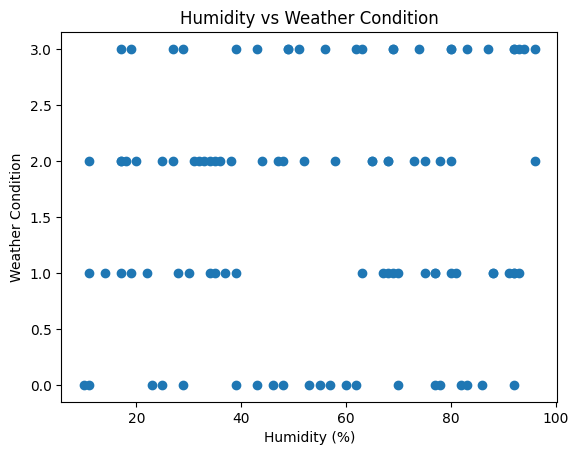

In [ ]:
#visualization
plt.scatter(df['Humidity (%)'], df['Weather Condition'])
plt.xlabel('Humidity (%)')
plt.ylabel('Weather Condition')
plt.title('Humidity vs Weather Condition')
plt.show()

In [ ]:
#model evalution
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 1.00


# **`On Small Data Set`**

### a Water Tank Capacity and Daily Usage Dataset

In [ ]:
import pandas as pd
import numpy as np
num_samples = 10
tank_capacity = np.full(num_samples, 2000)
daily_usage = np.random.randint(50, 500, num_samples)
water_data = pd.DataFrame({
    'Tank Capacity (liters)': tank_capacity,
    'Daily Usage (liters)': daily_usage
})

display(water_data.head())

,Tank Capacity (liters),Daily Usage (liters)
0,2000,398
1,2000,223
2,2000,119
3,2000,168
4,2000,118


In [ ]:
#average water consuption in aweek
avg_consuption=water_data['Daily Usage (liters)'].mean()
print(avg_consuption)

278.8


In [ ]:
#finding the daily usage how much increased
water_data['Daily Usage (liters)'] = water_data['Daily Usage (liters)'] - avg_consuption
print(water_data['Daily Usage (liters)'])

0    119.2
1    -55.8
2   -159.8
3   -110.8
4   -160.8
5     18.2
6   -105.8
7     79.2
8    205.2
9    171.2
Name: Daily Usage (liters), dtype: float64


In [ ]:
#total water usage
total_water_usage = water_data['Daily Usage (liters)'].sum()
print(total_water_usage)

-1.1368683772161603e-13


In [ ]:
num_samples = 10
tank_capacity = np.full(num_samples, 2000)
daily_usage = np.random.randint(50, 500, num_samples)
water_data = pd.DataFrame({
    'Tank Capacity (liters)': tank_capacity,
    'Daily Usage (liters)': daily_usage
})

avg_consuption = water_data['Daily Usage (liters)'].mean()
initial_capacity = water_data['Tank Capacity (liters)'].iloc[0]

if avg_consuption > 0:
    days_to_depletion = initial_capacity / avg_consuption
    print(f"Based on an average daily usage of {avg_consuption:.2f} liters, the tank will last approximately {days_to_depletion:.2f} days.")
else:
    print("Average daily usage is zero or negative")

Based on an average daily usage of 203.90 liters, the tank will last approximately 9.81 days.


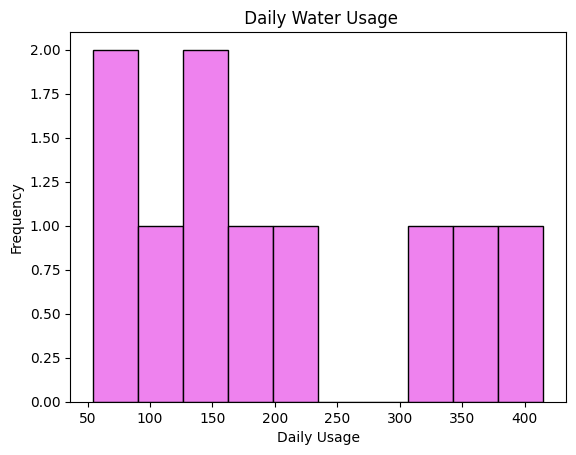

In [15]:
import matplotlib.pyplot as plt
plt.hist(water_data['Daily Usage (liters)'], bins=10, color='violet', edgecolor='black')
plt.xlabel('Daily Usage')
plt.ylabel('Frequency')
plt.title(' Daily Water Usage')
plt.show()